# **Projet final :** Comprendre l'asthme et ses causes

Par : Pietro Cosulich Menez, Amir Ebrahimi et Yassine Gharbi

Lien vers le dataset : <a href=https://www.kaggle.com/datasets/miadul/asthma-synthetic-medical-dataset>Asthma synthetic medical dataset </a>

##Introduction & SOTA :

Prédire l'asthme et son évolution grâce au machine learning est aujourd'hui un enjeu central dans la recherche épidémiologique. Aujourd’hui, le but de notre travail est d’essayer de prédire si une personne pourrait être atteinte d’asthme en fonction de différentes caractéristiques, attributs et mesures. Déterminer correctement ces dernières sera ainsi notre challenge, tout en les exploitant de la meilleure manière pour arriver à des résultats probants !

Pour définir la sévérité ou l'état de l'asthme, l'état de l'art se réfère de manière universelle aux directives de la **GINA (Global Initiative for Asthma)**. La GINA est un programme qui regroupe des personnels de soins de santé et les pouvoirs publics dans le but de faire diminuer la prévalence (le nombre de personnes atteintes), la morbidité (les symptômes engendrés) et la mortalité. Ainsi, les différents modèles prédictifs actuels cherchent soit à classifier la présence de la maladie, soit à anticiper une aggravation de ces stades GINA (allant du patient non traité aux stades 1 à 5).

Après avoir exploré de nombreuses études sur le sujet, la littérature met en lumière le comportement de différentes architectures sur ce genre de dataset. Voici les principaux outils employés :

**Forêts Aléatoires (Random Forest)** : Ces modèles se démarquent par leur excellente spécificité (jusqu'à 0,86 dans l'étude sur la cohorte Constances), ce qui réduit fortement les faux positifs. Ils apparaissent comme les plus performants et stables pour l'analyse des patients présentant une sévérité modérée.

**Support Vector Machines (SVM)** : Les SVM affichent la sensibilité la plus élevée (jusqu'à 0,82), et maximisent ainsi la détection des patients à risque, bien que cela se fasse parfois au détriment de la spécificité.

**Modèles linéaires et de proximité (Régression Logistique, KNN, Perceptron)** : Bien que performants globalement, ils s'avèrent souvent plus limités(notamment le KNN), justifiant notamment davantage l’utilisation d’arbres.

La sélection des données a une importance majeure dans les résultats. Parmi les indicateurs de pointe les plus prédictifs, on retrouve :

**Les biomarqueurs d'inflammation** : Le taux d'éosinophiles (un type de globules blancs) s'impose comme l'une des variables ayant le plus d'impact. Plus ce taux est élevé, plus le risque lié à la maladie augmente.

**L'historique des traitements et des soins** : La récurrence de délivrance de certains traitements (comme les préparations nasales ou l'historique des visites médicales d'urgence) constitue un signal faible mais crucial pour les algorithmes.

En nous inspirant des features (même si elles ne sont pas forcément à notre disposition) et en réutilisant des modèles efficaces, ces recherches vont nous servir de fil conducteur tout le long de notre projet.

Modules Pythons utilisés : <br>
1. Visualisation des données
- kagglehub
- pandas
- numpy
- matplotlib
- seaborn <br>
2. Entrainement et validation des modèles
- sklearn.model_selection
- sklearn.metrics
- sklearn.ensemble
- scipy.stats
- xgboost


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Chargement du jeu de données
import kagglehub
path = kagglehub.dataset_download("miadul/asthma-synthetic-medical-dataset")
df = pd.read_csv(path + '/synthetic_asthma_dataset.csv')

Using Colab cache for faster access to the 'asthma-synthetic-medical-dataset' dataset.


Aperçu des données :

In [ ]:
display(df.head())

,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN


## Prétraitement des Données

### Vérification initiale des Données

Les informations de DataFrame :

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               10000 non-null  object 
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   BMI                      10000 non-null  float64
 4   Smoking_Status           10000 non-null  object 
 5   Family_History           10000 non-null  int64  
 6   Allergies                7064 non-null   object 
 7   Air_Pollution_Level      10000 non-null  object 
 8   Physical_Activity_Level  10000 non-null  object 
 9   Occupation_Type          10000 non-null  object 
 10  Comorbidities            5033 non-null   object 
 11  Medication_Adherence     10000 non-null  float64
 12  Number_of_ER_Visits      10000 non-null  int64  
 13  Peak_Expiratory_Flow     10000 non-null  float64
 14  FeNO_Level             

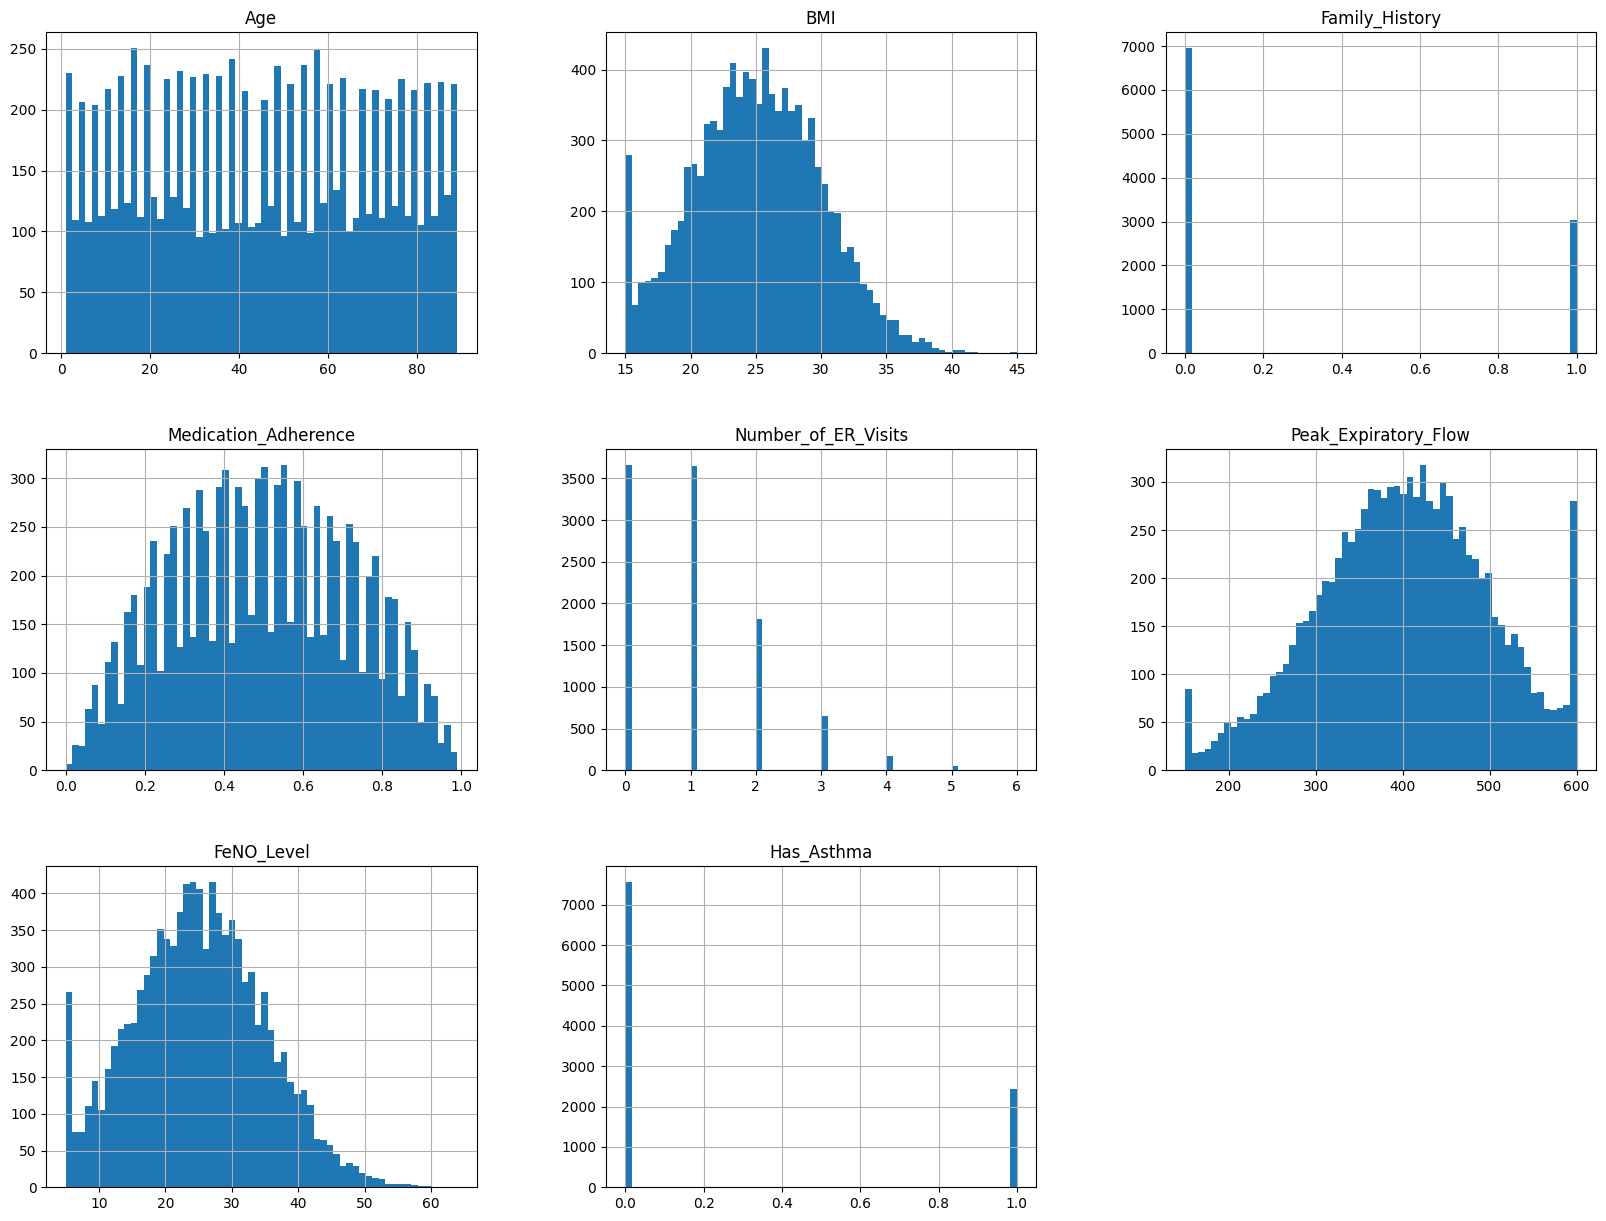

In [ ]:
df.hist(bins=60, figsize=(20,15))
plt.show()

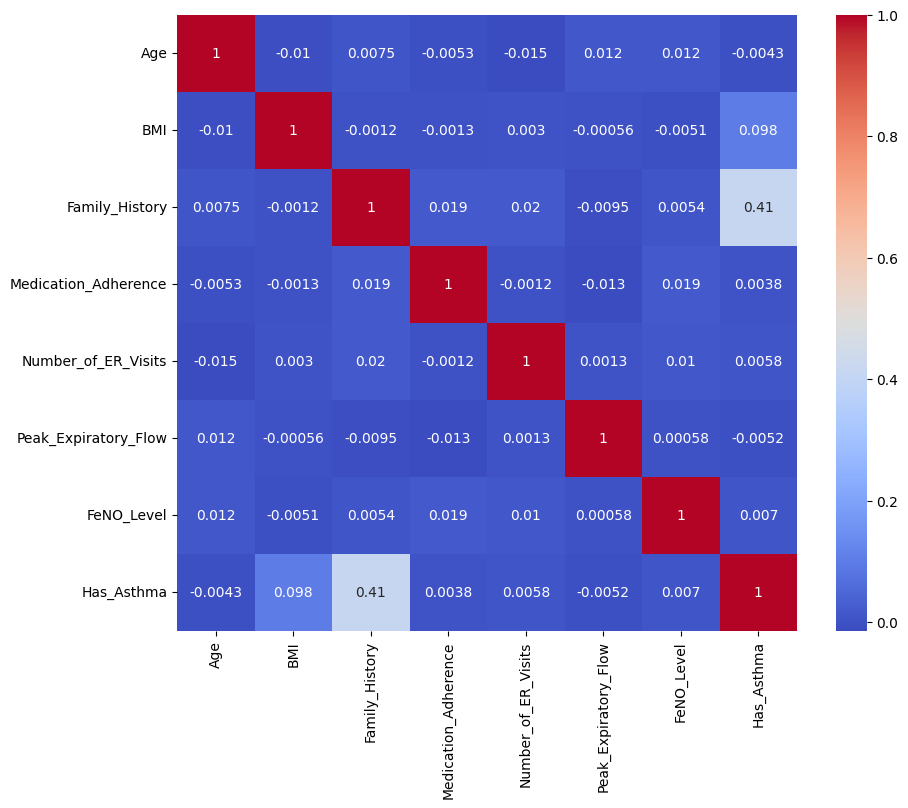

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Nombres des Valeurs Manquantes par Colonne :

In [ ]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Family_History,0
Allergies,2936
Air_Pollution_Level,0
Physical_Activity_Level,0
Occupation_Type,0


### Suppression des Colonnes Inutiles

Nous allons supprimer 'Patient_ID' car c'est un identifiant et non une caractéristique pertinente pour le modèle. Nous supprimerons également 'Asthma_Control_Level' en raison d'un nombre élevé de valeurs manquantes et de sa forte corrélation avec la variable cible 'Has_Asthma' (qui indique si un patient est asthmatique ou non), ce qui pourrait entraîner une fuite de données si elle était utilisée directement comme caractéristique.

In [ ]:
df.drop(columns=['Patient_ID', 'Asthma_Control_Level'], inplace=True)

le Dataset après suppression des colonnes :

In [ ]:
display(df.head())

,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma
0,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0
1,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0
2,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0
3,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1
4,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0


### Gestion des Valeurs Manquantes et des Caractéristiques Catégorielles

Tout d'abord, réexaminons les valeurs manquantes après la suppression des colonnes spécifiées.

In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Family_History,0
Allergies,2936
Air_Pollution_Level,0
Physical_Activity_Level,0
Occupation_Type,0
Comorbidities,4967


Pour les colonnes catégorielles avec des valeurs manquantes ('Allergies', 'Comorbidities'), nous allons les remplir avec la chaîne de caractères "NaN". Cette valeur sera ensuite mappée à 0 lors de l'encodage catégoriel. Pour les autres colonnes catégorielles, nous définirons un mappage direct vers des valeurs numériques.

In [ ]:
cleanup_nums = {"Gender": {"Female": 0, "Male": 1, "Other": -1},
                "Smoking_Status": {"Never": 0, "Former": 1, "Current": 2},
                "Allergies" : {"NaN" : 0, "Dust" : 1, "Pollen" : 2, "Pets" : 3, "Multiple" : 4},
                "Air_Pollution_Level": {"Low": 0, "Moderate": 1, "High": 2},
                "Physical_Activity_Level" : {"Sedentary" : 0, "Moderate" : 1, "Active" : 3},
                "Occupation_Type": {"Outdoor": 0, "Indoor": 1},
                "Comorbidities" : {"NaN" : 0, "Diabetes" : 1, "Hypertension" : 2, "Both" : 3},
                "Asthma_Control_Level" : {"NaN" : 0, "Not Controlled" : 1, "Poorly Controlled" : 2, "Well Controlled" : 3}
}

df = df.fillna("NaN")

df = df.replace(cleanup_nums)

/tmp/ipykernel_564/1634736598.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(cleanup_nums)


Le dataset après gestion des valeurs manquantes et encodage catégoriel :

In [ ]:
display(df.head())

,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma
0,52,0,27.6,1,1,0,1,0,0,1,0.38,0,421.0,46.0,0
1,15,1,24.6,1,0,1,0,1,1,3,0.60,2,297.6,22.9,0
2,72,0,17.6,0,0,0,1,1,1,0,0.38,0,303.3,15.3,0
3,61,1,16.8,0,0,4,2,0,0,3,0.60,1,438.0,40.1,1
4,21,1,30.2,0,0,0,1,3,1,0,0.82,3,535.0,27.7,0


Les Informations et les Types des Données mis à jour :

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      10000 non-null  int64  
 1   Gender                   10000 non-null  int64  
 2   BMI                      10000 non-null  float64
 3   Smoking_Status           10000 non-null  int64  
 4   Family_History           10000 non-null  int64  
 5   Allergies                10000 non-null  int64  
 6   Air_Pollution_Level      10000 non-null  int64  
 7   Physical_Activity_Level  10000 non-null  int64  
 8   Occupation_Type          10000 non-null  int64  
 9   Comorbidities            10000 non-null  int64  
 10  Medication_Adherence     10000 non-null  float64
 11  Number_of_ER_Visits      10000 non-null  int64  
 12  Peak_Expiratory_Flow     10000 non-null  float64
 13  FeNO_Level               10000 non-null  float64
 14  Has_Asthma             

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'Smoking_Status'}>],
       [<Axes: title={'center': 'Family_History'}>,
        <Axes: title={'center': 'Allergies'}>,
        <Axes: title={'center': 'Air_Pollution_Level'}>,
        <Axes: title={'center': 'Physical_Activity_Level'}>],
       [<Axes: title={'center': 'Occupation_Type'}>,
        <Axes: title={'center': 'Comorbidities'}>,
        <Axes: title={'center': 'Medication_Adherence'}>,
        <Axes: title={'center': 'Number_of_ER_Visits'}>],
       [<Axes: title={'center': 'Peak_Expiratory_Flow'}>,
        <Axes: title={'center': 'FeNO_Level'}>,
        <Axes: title={'center': 'Has_Asthma'}>, <Axes: >]], dtype=object)

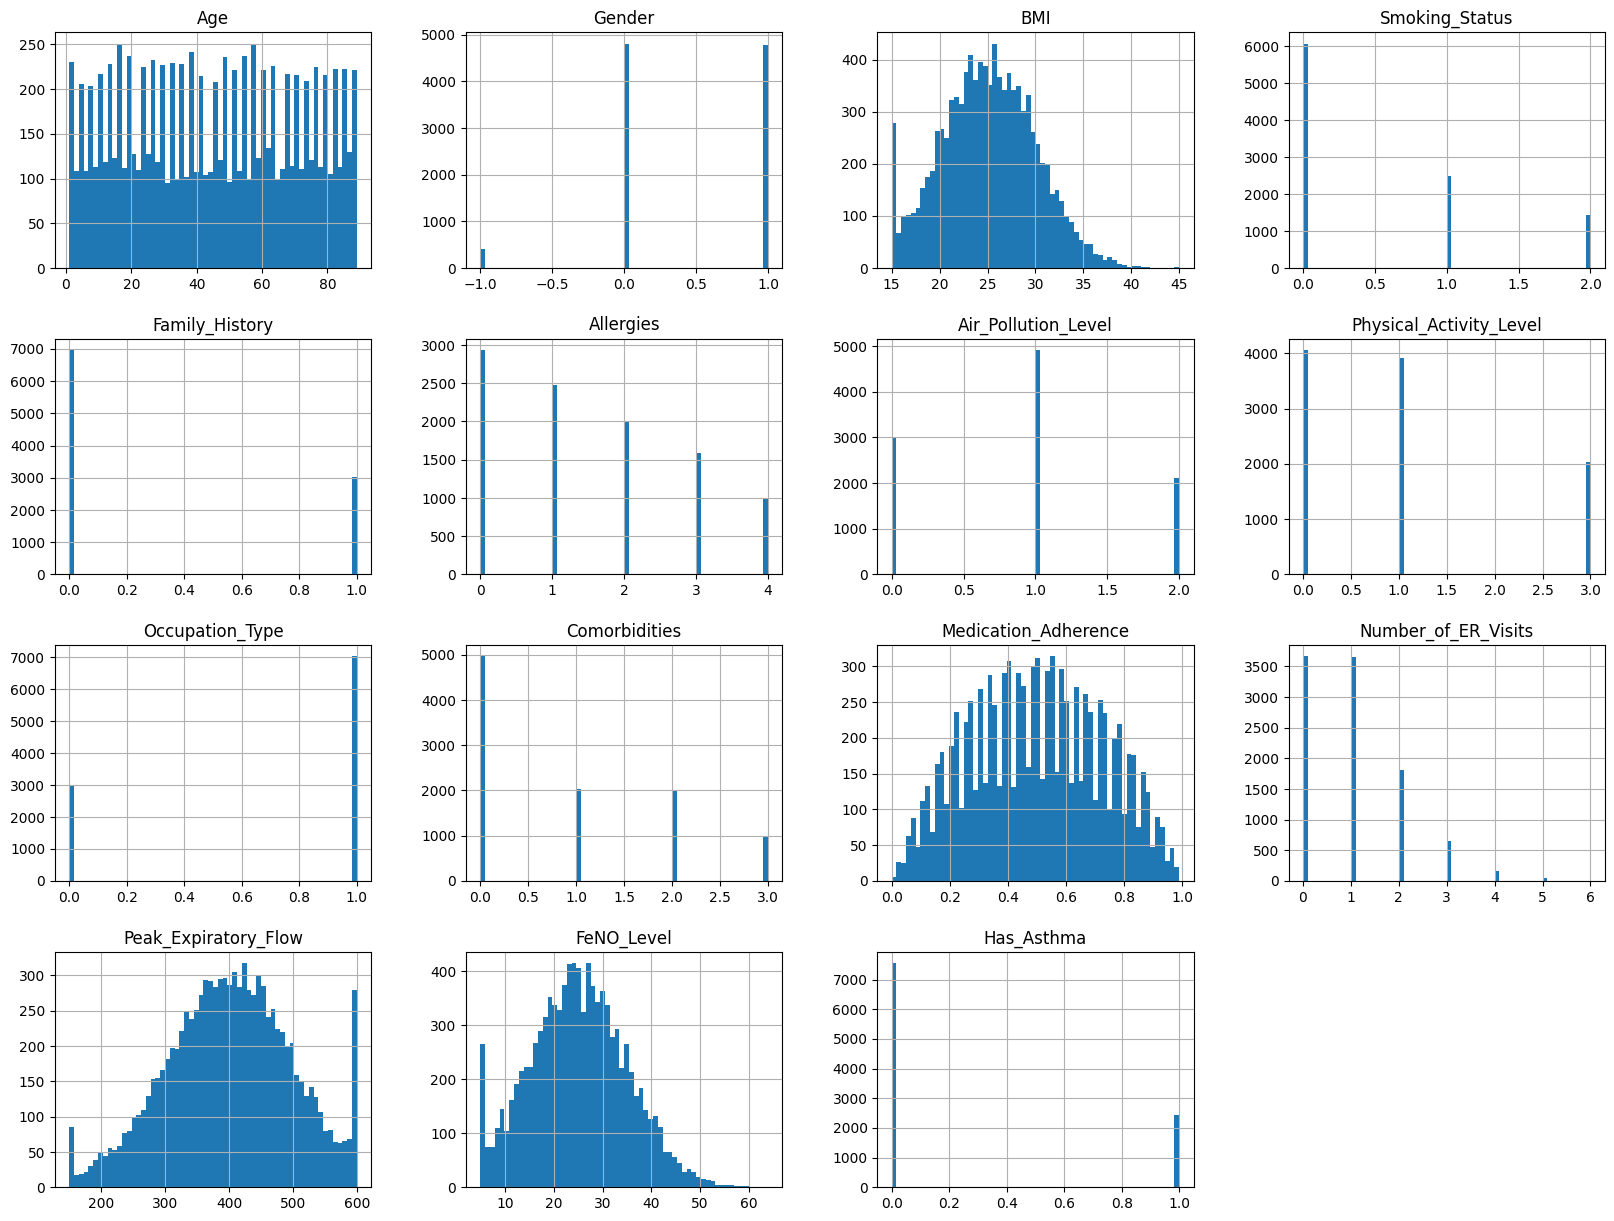

In [ ]:
df.hist(bins=60, figsize=(20,15))

### Feature Engineering

#### **Inflammation des voies aériennes basée sur le niveau de FeNO** :

Le FeNO (Fraction d’Oxyde Nitrique Exhalé) est un indicateur simple qui permet d’estimer le niveau d’inflammation dans les voies aériennes. Quand les bronches sont enflammées, surtout dans l’asthme de type allergique, les cellules des voies respiratoires produisent plus d’oxyde nitrique. Résultat : le FeNO augmente.

Dans notre projet, nous utilisons le FeNO comme un moyen d’évaluer l’intensité de l’inflammation bronchique. Plus le FeNO est élevé, plus l’inflammation est importante. Ce biomarqueur est utile pour :

- repérer une inflammation active,
- suivre l’évolution de l’asthme,
- voir si un traitement anti‑inflammatoire fonctionne.

Nous avons utilisé les seuils cliniques recommandés pour classer le FeNO en trois niveaux :

- 0 : faible
- 1 : intermédiaire
- 2 : élevé (inflammation importante)

Les seuils diffèrent légèrement entre les adultes et les enfants, comme indiqué dans les recommandations ATS. À partir de cette classification, nous avons ajouté une colonne booléenne indiquant simplement si l’inflammation est significative ou non. Cela permet d’avoir à la fois :

- la valeur brute du FeNO (plus précise),
- une version catégorisée (plus facile à interpréter),
- et un indicateur simple d’inflammation (oui/non).

Cette approche nous permet d’intégrer le FeNO dans l’analyse de manière cohérente, tout en respectant les seuils utilisés en pratique clinique.

##### **les ressources** :

- The Role of FeNO in Asthma Management : https://pmc.ncbi.nlm.nih.gov/articles/PMC10137365/

- Why is FeNO elevated in asthma : https://allergyasthmanetwork.org/what-is-asthma/how-is-asthma-diagnosed/nitric-oxide-testing/

In [ ]:
# Estimation du niveau d'inflammation

def inflammation_level(feno, age):
    # Enfants
    if age < 18:
        if feno < 20:
            return 0 #faible
        elif feno <= 35:
            return 1 #intermédiaire
        else:
            return 2 #élevé

    # Adultes (≥18)
    else:
        if feno < 25:
            return 0 #faible
        elif feno <= 50:
            return 1 #intermédiaire
        else:
            return 2 #élevé

# Application au dataset

df["Inflammation_Level"] = df.apply(lambda row: inflammation_level(row["FeNO_Level"], row["Age"]), axis=1)

#### **Le rôle de PEFR (le débit expiratoire maximal) dans le diagnostic et la prise en charge de l’asthme**  :

Le PEFR (Peak Expiratory Flow Rate) est une mesure qui indique à quelle vitesse une personne peut expirer l’air de ses poumons. C’est un test très utilisé en asthme, car il permet de voir si les bronches sont bien ouvertes ou si elles sont rétrécies. Quand les voies respiratoires sont enflammées ou contractées, le PEFR diminue. C’est donc un indicateur simple pour suivre l’évolution de la respiration d’un patient.

Pour interpréter correctement un PEFR mesuré, il faut le comparer à un PEFR normal, c’est‑à‑dire la valeur qu’une personne en bonne santé devrait avoir. Ce PEFR normal dépend de l’âge, le sexe, et surtout la taille, car la taille influence directement la capacité pulmonaire.

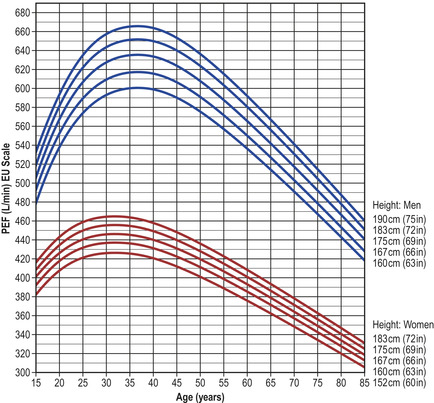


Les formules médicales officielles utilisent donc la taille pour calculer cette valeur théorique.

- Enfants:

      𝑃𝐸𝐹𝑅 = (5 ⋅ (𝐻 en cm − 100)) + 100

- Hommes :

      𝑃𝐸𝐹𝑅 = (((5.48 ⋅ 𝐻 en m) + 1.58) - (𝐴𝑔𝑒 ⋅ 0.041)) ⋅ 60

- Femmes :

      𝑃𝐸𝐹𝑅 = (((3.72 ⋅ 𝐻 en m) + 2.24) - (𝐴𝑔𝑒 ⋅ 0.03)) ⋅ 60

Dans notre dataset, la taille n’est pas disponible. Nous n’avons que l’âge, le BMI et le genre. Comme le BMI ne permet pas de retrouver la taille exacte, nous ne pouvons pas appliquer directement les formules médicales.

Pour résoudre ce problème, nous avons adopté une approche **probabiliste bayésienne** permettant d’estimer une taille plausible à partir du BMI et du genre. L’idée repose sur le fait que, dans une population saine, la taille suit une distribution normale spécifique à chaque sexe, et que les variations du BMI autour de la valeur de référence (≈22) sont corrélées à des variations de taille moyennes. Nous avons donc modélisé la taille estimée comme :

    𝐻 = 𝜇_𝐻,𝑔𝑒𝑛𝑟𝑒 + 𝛼 ⋅ (𝐵𝑀𝐼 − 22)

Les valeurs de **𝛼** ont été choisies parce que le BMI influence la taille, mais seulement de manière faible. Ce n’est pas une relation directe, juste une tendance statistique observée dans la population.

De plus, il est important de ne pas déformer la taille estimée : un BMI très élevé ou très bas ne doit pas produire une taille irréaliste.

Les **𝛼** permettent donc d’ajuster légèrement la taille autour de la moyenne, sans créer de valeurs extrêmes.

Cette méthode nous permet d’obtenir une valeur de PEFR normal cohérente pour chaque individu, même sans connaître sa taille réelle, et donc de comparer le PEFR mesuré avec une valeur de référence.

##### **les ressources** :

- Journal of Clinical Respiratory Diseases & Care :
https://www.hilarispublisher.com/open-access/the-role-of-peak-expiratory-flow-rate-in-asthma-diagnosis-and-management-107301.html

- Peak flow recording :
https://patient.info/doctor/history-examination/peak-flow-recording

- Peak flow calculator (pour les formules) :
https://www.mdapp.co/peak-flow-calculator-76/

In [ ]:
# Estimation bayésienne de la taille

def estimate_height_bayesian(age, bmi, gender):
    # pour les enfants on utilise une estimation simple basée sur les courbes de croissance.
    if age < 18:
        if gender == 1:  # Male
            return 75 + 6.5 * age
        else:            # Female
            return 72 + 6.0 * age

    if gender == 1:  # Male
        mean_height = 175
        alpha = -0.9
    else:            # Female
        mean_height = 162
        alpha = -0.7

    estimated_height = mean_height + alpha * (bmi - 22)

    return estimated_height


# Calcul du PEFR normal

def normal_pefr(age, height, gender):

    if age < 18:
        return (5 * (height - 100)) + 100
    else :
      height = height / 100
      if gender == 1:  # Male
          return (((5.48 * height) + 1.58) - (0.041 * age)) * 60
      else:            # Female
          return (((3.72 * height) + 2.24) - (0.03 * age))  * 60


# Calcul du score PEFR

def score_pefr(age, bmi, gender, pef):
    height = estimate_height_bayesian(age, bmi, gender)
    return (pef / normal_pefr(age, height, gender)) * 100


# Application au dataset

df["Score PEFR"] = df.apply(
    lambda row: score_pefr(row["Age"], row["BMI"], row["Gender"], row["Peak_Expiratory_Flow"]),
    axis=1
)

le Dataset final :

In [ ]:
display(df.head())

,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Inflammation_Level,Score PEFR
0,52,0,27.6,1,1,0,1,0,0,1,0.38,0,421.0,46.0,0,1,106.951991
1,15,1,24.6,1,0,1,0,1,1,3,0.60,2,297.6,22.9,0,1,64.345946
2,72,0,17.6,0,0,0,1,1,1,0,0.38,0,303.3,15.3,0,0,81.257346
3,61,1,16.8,0,0,4,2,0,0,3,0.60,1,438.0,40.1,1,1,81.788465
4,21,1,30.2,0,0,0,1,3,1,0,0.82,3,535.0,27.7,0,1,90.025728


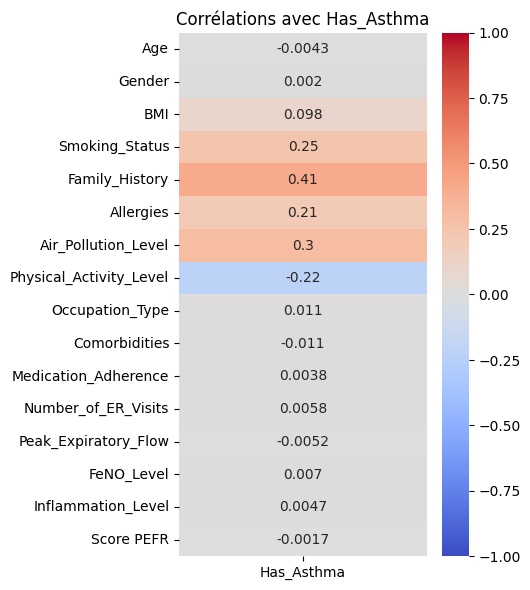

In [ ]:
corr_matrix = df.corr(numeric_only=True)
corr_asthma = corr_matrix[["Has_Asthma"]]

plt.figure(figsize=(4, len(corr_asthma)*0.4))
sns.heatmap(corr_asthma.drop(["Has_Asthma"]), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Corrélations avec Has_Asthma")
plt.show()

### Division des Données en Ensembles d'Entraînement, de Validation et de Test

Nous allons séparer notre dataset en 3 parties :
- Training (60%) : Entrainement de nos modèles.
- Validation (20%) : Phase de pre-validation avant le test. Le but est de ne garder que les modèles ayant dépassé un seuil (0.80) de score.
- Test (20%) : Phase de test finale. On teste les modèles restants afin d'évaluer leurs performances.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Has_Asthma', axis=1)
y = df['Has_Asthma']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Nous divisons maintenant l'ensemble d'entraînement (`X_train`, `y_train`) en un nouvel ensemble d'entraînement et un ensemble de validation pour l'ajustement du modèle et la sélection des hyperparamètres.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train,
    test_size=0.25,  # 25% de l'ensemble d'entraînement original, soit 20% du total (0.25 * 0.8 = 0.2)
    stratify=y_train,
    random_state=42,
)

print("Taille X_train :", X_train.shape)
print("Taille X_val :", X_valid.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_val :", y_valid.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (6000, 16)
Taille X_val : (2000, 16)
Taille X_test : (2000, 16)
Taille y_train : (6000,)
Taille y_val : (2000,)
Taille y_test : (2000,)


#### Application de l'ACP afin de choisir les déscripteurs les plus pertinents ainsi que réduire la dimensionnalité

In [ ]:
commentfrom sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def apply_pca(X_train, X_valid, X_test):

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_valid_pca = pca.transform(X_valid_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    return X_train_pca, X_valid_pca, X_test_pca

In [ ]:
X_train_pca, X_valid_pca, X_test_pca = apply_pca(X_train, X_valid, X_test)

## Classification

### Partie Training/Validation

L'objectif de ce projet est de faire de la classification binaire.
Cependant, il faut prendre en compte le deséquilibre qui existe entre le nombre de personnes atteintes d'asthme et celles non-atteintes.

Nous avons donc choisi d'implémenter 4 modèles :
- **Régression Logistique**
- **Random Forest**
- **Gradient Boosting**
- **XGBoost**


Choix de la métrique :
- L'**accuracy** n'est pas pertinente car nos classes sont déséquilibrées. <br>
- La **précision** nous permettrait de mesurer le taux de faux positifs. <br>
- Le **recall** nous permet de mesurer combien de personnes asthmatiques ont été correctement classées parmi le nombre totale d'asthmatiques. <br>
- **F1-Score** serait parfaitement adapté pour notre dataset déséquilibré car il combine les deux métriques précédentes.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

In [ ]:
def evaluate_all_metrics(y_true, y_pred):
    results = {
        "Precision": precision_score(y_true, y_pred, average='binary'),
        "Recall": recall_score(y_true, y_pred, average='binary'),
        "F1-score": f1_score(y_true, y_pred, average='binary'),
    }
    return results

### Régression Logistique

#### Données Brutes

In [ ]:
from sklearn.linear_model import LogisticRegression
rl = LogisticRegression(max_iter=1000)
rl.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_valid_pred = rl.predict(X_valid)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,0.782506
Recall,0.681070
F1-score,0.728273


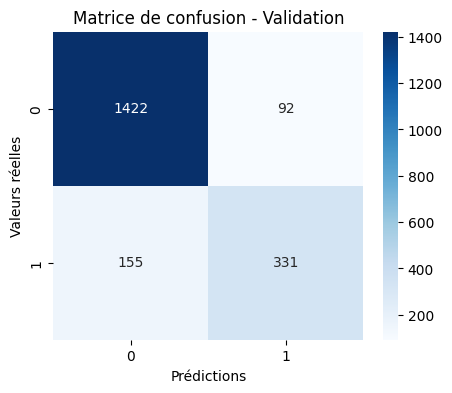

In [ ]:
cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Validation")
plt.show()

#### Application du ACP

In [ ]:
rl_pca = LogisticRegression(max_iter=1000)
rl_pca.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_valid_pred = rl_pca.predict(X_valid_pca)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,0.785548
Recall,0.693416
F1-score,0.736612


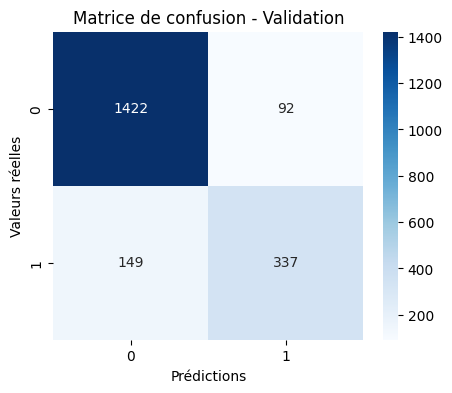

In [ ]:
cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Validation")
plt.show()

### Random Forest

#### Données Brutes

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"   # utile car dataset déséquilibré
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_valid_pred = rf.predict(X_valid)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,1.000000
Recall,0.985597
F1-score,0.992746


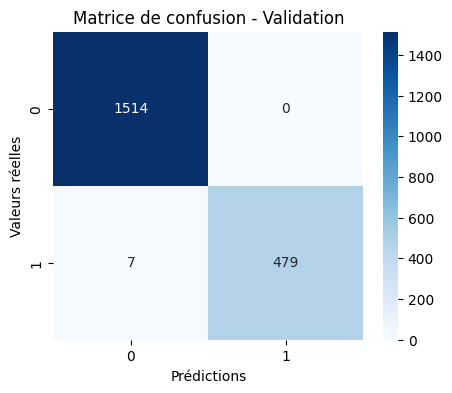

In [ ]:
cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Validation")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators": randint(100, 200),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,               # nombre d'essais
    scoring="f1",            # métrique à optimiser
    cv=5,                    # cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1                # parallélisation
)

random_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", random_search.best_params_)
print("Meilleur score CV :", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs hyperparamètres : {'bootstrap': False, 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 191}
Meilleur score CV : 0.997260261943528


### Gradient Boost

#### Données Brutes

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_valid_pred = gb.predict(X_valid)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,1.0
Recall,1.0
F1-score,1.0


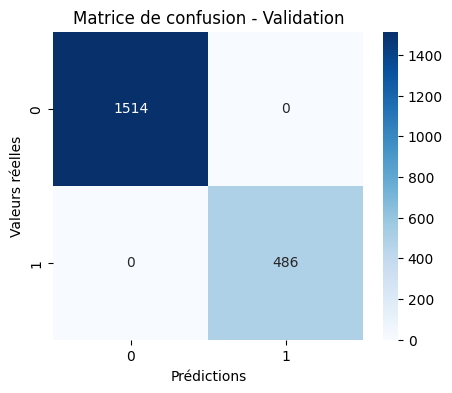

In [ ]:
y_valid_pred = gb.predict(X_valid)

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Validation")
plt.show()

#### Application du ACP

In [ ]:
gb_pca = GradientBoostingClassifier(random_state=42)
gb_pca.fit(X_train_pca, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_valid_pred = gb_pca.predict(X_valid_pca)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,0.869565
Recall,0.658436
F1-score,0.749415


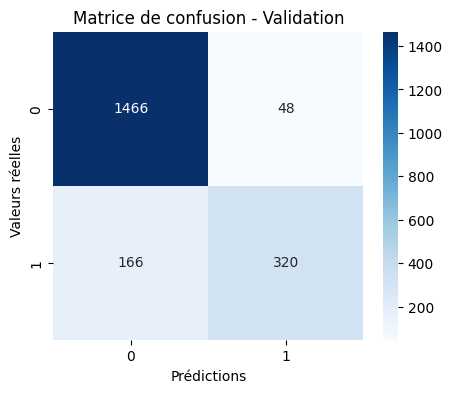

In [ ]:
cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Validation")
plt.show()

### XGBoosting

#### Données Brutes

In [ ]:
import xgboost

In [ ]:
xgb = xgboost.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_valid_pred = xgb.predict(X_valid)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,1.0
Recall,1.0
F1-score,1.0


#### Application du ACP

In [ ]:
xgb_pca = xgboost.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
xgb_pca.fit(X_train_pca, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_valid_pred = xgb_pca.predict(X_valid_pca)
scores = evaluate_all_metrics(y_valid, y_valid_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,0.906542
Recall,0.798354
F1-score,0.849015


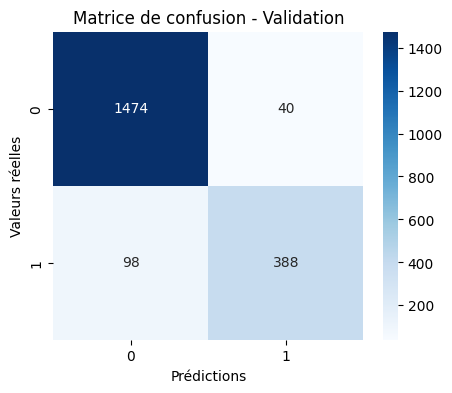

In [ ]:
cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion - Validation")
plt.show()

Nous pouvons remarquer que l'application de l'ACP sur nos modèles n'a fait que réduire les performances de nos modèles (jusqu'à 0.3 points de score perdus) sauf pour la régression logistique qui a eu une amélioration négligeable de 0.01 point de score.

## Phase Test

Résultats des modèles :
- Régression Logistique (avec ACP) : ~ 0.73
- Random Forest : 0.99
- Gradient Boost : 1.0
- XGBoost : 1.0 <br>

On remarque que la régression logistique est le seul modèle à ne pas valider le seuil choisi (0.80). Testons maintenant nos modèles restants afin d'évaluer leurs performances sur les données restantes.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

def cv_evaluate_and_plot(model, X, y, cv=5, scoring="f1"):
    """
    Effectue une validation croisée, affiche un graphique,
    et retourne les scores.
    """

    # Stratified K-Fold pour dataset déséquilibré
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    # Scores CV
    scores = cross_val_score(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)

    # Affichage
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, cv+1), scores, marker='o', linestyle='-', color='royalblue')
    plt.axhline(np.mean(scores), color='red', linestyle='--', label=f"Moyenne = {scores.mean():.3f}")
    plt.title(f"Validation croisée ({model.__class__.__name__}) — scoring = {scoring}")
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.xticks(range(1, cv+1))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Scores par fold : {scores}")
    print(f"Score moyen : {scores.mean():.4f}")
    print(f"Écart-type : {scores.std():.4f}")

    return scores

### Random Forest

#### Données Brutes

In [ ]:
y_test_pred = rf.predict(X_test)
scores = evaluate_all_metrics(y_test, y_test_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,1.000000
Recall,0.987680
F1-score,0.993802


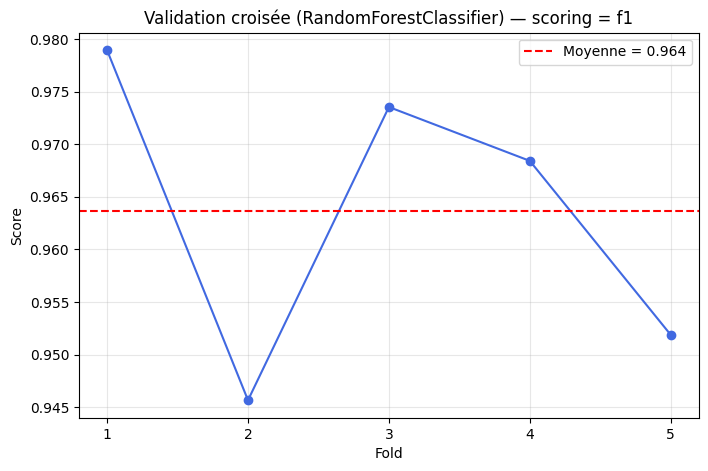

Scores par fold : [0.97894737 0.94565217 0.97354497 0.96842105 0.95187166]
Score moyen : 0.9637
Écart-type : 0.0128


array([0.97894737, 0.94565217, 0.97354497, 0.96842105, 0.95187166])

In [ ]:
cv_evaluate_and_plot(rf, X_test, y_test)

### Gradient Boost

#### Données Brutes

In [ ]:
y_test_pred = gb.predict(X_test)
scores = evaluate_all_metrics(y_test, y_test_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,1.0
Recall,1.0
F1-score,1.0


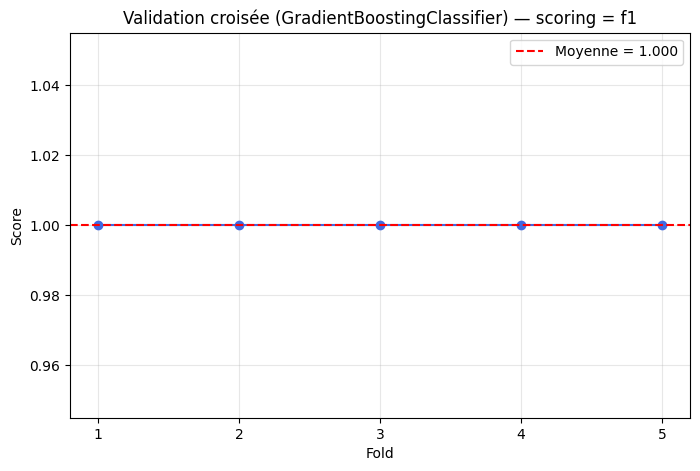

Scores par fold : [1. 1. 1. 1. 1.]
Score moyen : 1.0000
Écart-type : 0.0000


array([1., 1., 1., 1., 1.])

In [ ]:
cv_evaluate_and_plot(gb, X_test, y_test)

#### Application ACP

In [ ]:
y_test_pred = gb_pca.predict(X_test_pca)
scores = evaluate_all_metrics(y_test, y_test_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,0.882353
Recall,0.646817
F1-score,0.746445


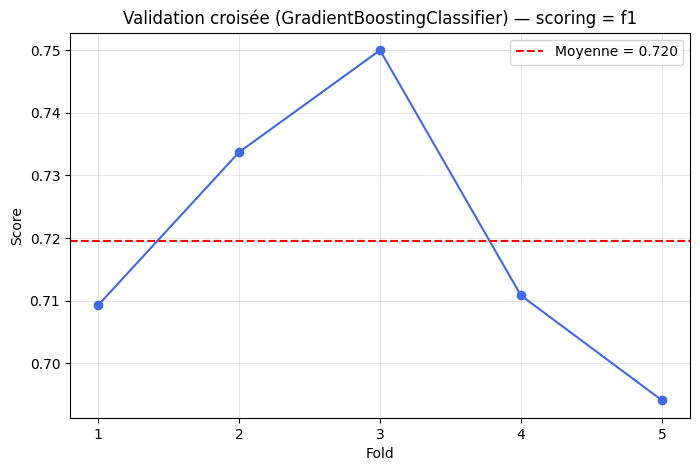

Scores par fold : [0.70930233 0.73372781 0.75       0.71084337 0.69411765]
Score moyen : 0.7196
Écart-type : 0.0198


array([0.70930233, 0.73372781, 0.75      , 0.71084337, 0.69411765])

In [ ]:
cv_evaluate_and_plot(gb_pca, X_test_pca, y_test)

### XGBoost

#### Données Brutes

In [ ]:
y_test_pred = xgb.predict(X_test)
scores = evaluate_all_metrics(y_test, y_test_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,1.0
Recall,1.0
F1-score,1.0


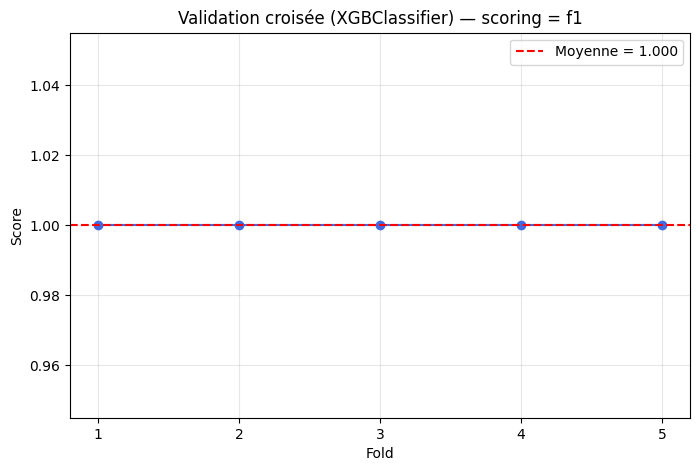

Scores par fold : [1. 1. 1. 1. 1.]
Score moyen : 1.0000
Écart-type : 0.0000


array([1., 1., 1., 1., 1.])

In [ ]:
cv_evaluate_and_plot(xgb, X_test, y_test)

#### Application ACP

In [ ]:
y_test_pred = xgb_pca.predict(X_test_pca)
scores = evaluate_all_metrics(y_test, y_test_pred)
df_scores = pd.DataFrame(scores, index=["Score"]).T
df_scores

,Score
Precision,0.905312
Recall,0.804928
F1-score,0.852174


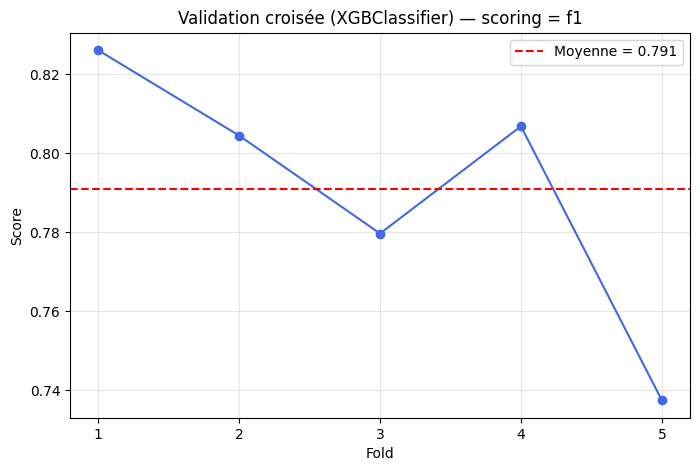

Scores par fold : [0.82608696 0.80446927 0.77966102 0.80681818 0.73743017]
Score moyen : 0.7909
Écart-type : 0.0305


array([0.82608696, 0.80446927, 0.77966102, 0.80681818, 0.73743017])

In [ ]:
cv_evaluate_and_plot(xgb_pca, X_test_pca, y_test)

##Validation croisée

Nous avons soumis nos modèles à une validation croisée stratifiée en 5 folds, pour ajouter une certaine robustesse à nos résultats.

L'analyse de notre graphique de validation croisée confirme la hiérarchie finale de nos modèles : la Régression Logistique montre des faiblesses et limites (F1-score de 0.72), alors que le Random Forest, le Gradient Boosting et XGBoost affichent d'excellents résultats, frôlant la perfection (0.99 à 1.00).

Régression Logistique -> F1-Score Moyen: 0.7183 (+/- 0.0174)
Random Forest -> F1-Score Moyen: 0.9987 (+/- 0.0012)
Gradient Boosting -> F1-Score Moyen: 1.0000 (+/- 0.0000)
XGBoost -> F1-Score Moyen: 1.0000 (+/- 0.0000)


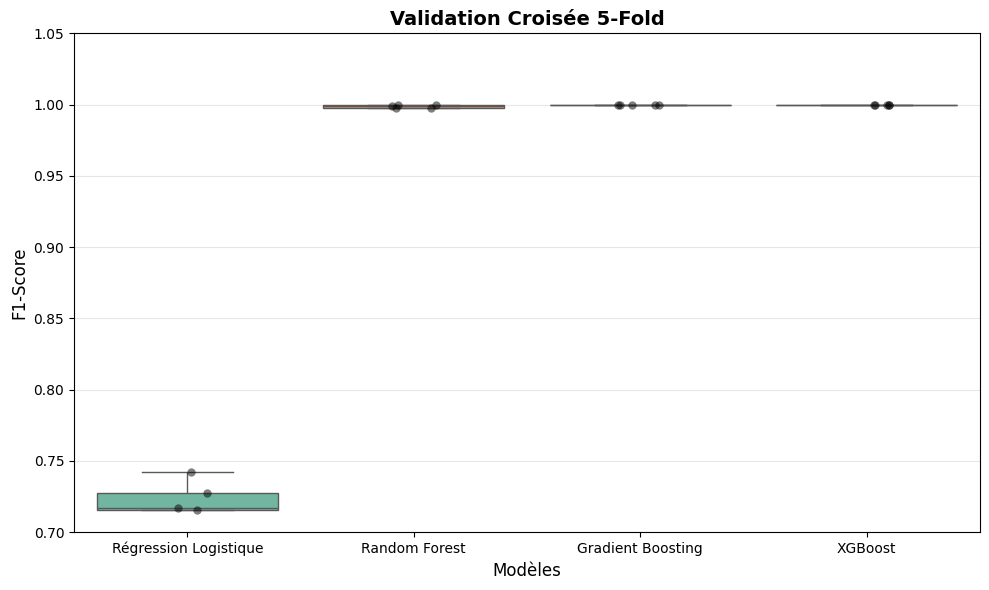

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_cv_global = pd.concat([X_train, X_valid])
y_cv_global = pd.concat([y_train, y_valid])

# (Re)Définition des architectures de modèles vierges (non entraînés)
modeles_vierges = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(**random_search.best_params_, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgboost.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=4,
        learning_rate=0.1,
        n_estimators=300,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
}

# Configuration du Stratified K-Fold (5 blocs étanches)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Exécution de la validation croisée et des F1-scores
resultats_cv = {}
for nom, mdl in modeles_vierges.items():
    scores = cross_val_score(mdl, X_cv_global, y_cv_global, cv=skf, scoring="f1", n_jobs=-1)
    resultats_cv[nom] = scores
    print(f"{nom} -> F1-Score Moyen: {scores.mean():.4f} (+/- {scores.std():.4f})")

df_cv = pd.DataFrame(resultats_cv)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cv, palette="Set2")
sns.stripplot(data=df_cv, color="black", alpha=0.5, jitter=0.1, size=6)

plt.title("Validation Croisée 5-Fold", fontsize=14, fontweight='bold')
plt.ylabel("F1-Score", fontsize=12)
plt.xlabel("Modèles", fontsize=12)
plt.ylim(0.7, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##Conclusion

Sur le plan médical et épidémiologique, l'analyse de l'importance des caractéristiques met en évidence que les facteurs environnementaux et héréditaires (tels que les antécédents familiaux et le niveau de pollution de l'air) sont les prédicteurs les plus puissants de l'asthme dans ce modèle.

Mais l'un des enseignements majeurs de ce projet réside dans la nature même des données avec lesquelles nous avons travaillé. En effet, nous avons vite compris qu'un jeu de données synthétique nous a permis de vite arriver, avec les bons modèles, à des scores quasi-parfaits (proches de 1.00). Cela ne traduit pas forcement une erreur, mais prouve plutot que ces algorithmes (d'arbres principalement) ont vite compris la logique qui a servi à générer informatiquement ce dataset.

Ainsi, pour conclure, si les modèles de Boosting s'imposent comme étant les plus efficaces sur nos données, la prochaine étape pour généraliser notre recherche serait de confronter nos modèles entraînés à un véritable dataset clinique hospitalier et affronter le monde réel épidémiologique.

**Sources :** https://ginasthma.org/wp-content/uploads/2026/05/GINA-2026-Strategy-Report-WMS.pdf

https://www.sciencedirect.com/science/article/pii/S039876202200788X

https://fr.wikipedia.org/wiki/Constances_(cohorte)
